In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import umap
from node2vec import Node2Vec
from tqdm.notebook import tqdm

### Opis danych wejściowych

Zbiór **CIFAR-10** zawiera obrazy o rozdzielczości $32×32$ piksele należące do dziesięciu klas:

- **airplane** - samolot,
- **automobile** - samochód osobowy,
- **bird** - ptak,
- **cat** - kot,
- **deer** - jeleń,
- **dog** - pies,
- **frog** - żaba,
- **horse** - koń,
- **ship** - statek,
- **truck** - ciężarówka.

Każda klasa jest reprezentowana przez $6000$ obrazów, co daje łącznie $60 000$ przykładów. Obrazy są równomiernie rozłożone pomiędzy klasy, dzięki czemu zbiór jest zbalansowany. Standardowy podział zbioru obejmuje $50 000$ obrazów treningowych oraz $10 000$ obrazów testowych. W projekcie dane wejściowe reprezentowane są jako tensory obrazów RGB o wymiarach $3 \times 32 \times 32$,  gdzie liczba $3$ odpowiada kanałom kolorów RGB, natomiast wymiary $32×32$ określają rozdzielczość obrazu.

In [12]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset_full = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset_full = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

classes = train_dataset_full.classes

print("Klasy:", classes)
print("Pełny zbiór treningowy:", len(train_dataset_full))
print("Pełny zbiór testowy:", len(test_dataset_full))

Klasy: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Pełny zbiór treningowy: 50000
Pełny zbiór testowy: 10000


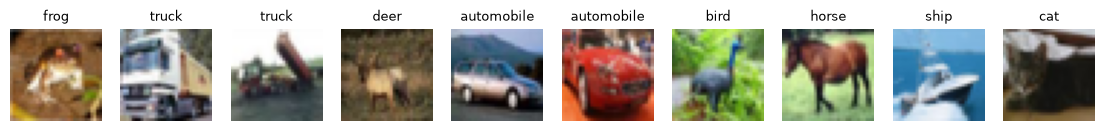

In [13]:
def show_images(dataset, n=10):
    plt.figure(figsize=(14, 3))

    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0).numpy()

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(classes[label], fontsize=9)
        plt.axis("off")

    plt.show()

show_images(train_dataset_full, n=10)

In [4]:
# %% [markdown]
# # CIFAR-10 jako Grafy Losowe (Z Ensemblingiem i Kompleksową Ewaluacją)
# Ten notatnik wdraża pełny plan:
# Część I: Generacja grafów losowych (DropEdge, Small-World)
# Część II: Agregacja cech za pomocą zespołu grafów (Ensembling)
# Część III: Fuzja determinizmu z losowością (HOG + grafy Erdősa-Rényiego)
# CZĘŚĆ IV: Kompleksowa ewaluacja (Accuracy, Macro F1, Reconstruction MSE, t-SNE, UMAP)

# %% [kod] Komórka 1: Importy bibliotek i Konfiguracja
import os
import sys
import time
import warnings
from dataclasses import dataclass, field

import numpy as np
import networkx as nx
from joblib import Parallel, delayed
warnings.filterwarnings("ignore")

import torchvision
import torchvision.transforms as transforms
from skimage.segmentation import slic
from skimage.color import rgb2lab
from skimage.feature import hog

# --- NOWE IMPORTY DLA ZAAWANSOWANEJ EWALUACJI ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import seaborn as sns
# ------------------------------------------------

@dataclass
class Config:
    data_dir: str = "./data"
    out_dir: str = "results_cifar_random"
    classes: list[int] = field(default_factory=lambda: [0, 1]) # Domyślnie 2 klasy do szybkiego testu
    per_class: int = 50
    
    # --- CZĘŚĆ I: PARAMETRY GRAFÓW LOSOWICH ---
    probabilistic: bool = True                 # 1. Prawdopodobieństwo zamiast twardego progu (DropEdge)
    small_world_p: float = 0.05                # 2. Szansa na dodanie dalekiego skrótu (Small-World)
    
    # --- CZĘŚĆ II: ENSEMBLING ---
    ensemble_m: int = 5                        # M - liczba losowych grafów budowanych dla JEDNEGO obrazu
    
    # --- CZĘŚĆ III: FUZJA ---
    er_p: float = 0.2                          # Prawdopodobieństwo krawędzi w czysto losowym grafie ER
    
    # Parametry bazowe obrazu/krawędzi
    tau: float = None
    edge_quantile: float = 0.6
    connectivity: int = 8
    n_segments: int = 60                       # Celowa liczba superpikseli SLIC
    compactness: float = 10.0
    sigma_pixel: float = 15.0
    sigma_feat: float = 1.0
    cv_folds: int = 5
    n_jobs: int = -1
    seed: int = 42

cfg = Config()

In [5]:
# %% [kod] Komórka 2: Wczytywanie Danych
def load_cifar10(cfg: Config):
    """Pobieranie CIFAR-10 i selekcja podzbioru klas/próbek."""
    transform = transforms.Compose([transforms.ToTensor()])
    ds = torchvision.datasets.CIFAR10(root=cfg.data_dir, train=True,
                                      download=True, transform=transform)
    targets = np.array(ds.targets)
    keep = cfg.classes if cfg.classes is not None else list(range(10))
    remap = {c: i for i, c in enumerate(keep)}

    rng = np.random.default_rng(cfg.seed)
    idxs = []
    if cfg.per_class is not None:
        for c in keep:
            pool = np.where(targets == c)[0]
            idxs.extend(rng.choice(pool, min(cfg.per_class, len(pool)), replace=False))
    idxs = np.array(sorted(int(i) for i in idxs))

    images, labels = [], []
    for i in idxs:
        img, lab = ds[int(i)]
        images.append(img.permute(1, 2, 0).numpy().astype(np.float32))
        labels.append(remap[int(lab)])
    return images, np.array(labels, dtype=int)

1. Obraz zostaje podzielony na zbiór rozłącznych superpikseli (regionów) $S = \{S_1, S_2, \dots, S_K\}$, gdzie $\bigcup_{i=1}^K S_i$ stanowi całą dziedzinę obrazu.
Każdy superpiksel staje się wierzchołkiem grafu: $V = \{1, 2, \dots, K\}$. Wykorzystany został algorytm segmentacji SLIC.

2. Algorytm iteruje po wszystkich pikselach i sprawdza sąsiedztwo w pionie i poziomie. Dla każdych dwóch sąsiadujących pikseli należących do różnych superpikseli $u$ i $v$, zwiększany jest licznik granicy.
Niech $B(u, v)$ oznacza długość granicy między superpikselem $S_u$ a $S_v$ (liczbę stycznych pikseli).
Obliczana jest również maksymalna długość granicy w całym grafie:

$$
B_{max} = \max_{(u,v)} B(u,v)
$$

3. Dla każdego wierzchołka $v \in V$ (odpowiadającego superpikselowi $S_v$) obliczane są jego atrybuty. Niech $x_i$ będzie wektorem koloru (np. RGB) dla $i$-tego piksela.

Rozmiar (rozłączność): $|S_v| = \sum_{x_i \in S_v} 1$

Pozycja (środek ciężkości): $p_v = \frac{1}{|S_v|} \sum_{x_i \in S_v} \text{pos}(x_i)$

Cechy wizualne ($f_v$): Konkatenacja średniej ($\mu_v$) i odchylenia standardowego ($\sigma_v$) kolorów pikseli w superpikselu:


$$\mu_v = \frac{1}{|S_v|} \sum_{x_i \in S_v} x_i$$

$$\sigma_v = \sqrt{\frac{1}{|S_v|} \sum_{x_i \in S_v} (x_i - \mu_v)^2}$$

$$f_v = [\mu_v, \sigma_v] \in \mathbb{R}^6$$

4: Generowanie kandydujących krawędzi
Dla każdej pary wierzchołków $(u, v)$, które mają wspólną granicę ($B(u,v) > 0$), obliczany jest dystans euklidesowy w przestrzeni średnich kolorów:


$$d(u,v) = \| \mu_u - \mu_v \|_2$$


Na podstawie tego dystansu obliczana jest waga podobieństwa (jądro Gaussa), która posłuży jako prawdopodobieństwo w modelu losowym:


$$w_{color}(u,v) = \exp\left(-\frac{d(u,v)^2}{2\sigma_{feat}^2}\right)$$


Jednocześnie dla każdego wierzchołka $u$ algorytm zapamiętuje swojego "najlepszego sąsiada" $v^*$, czyli takiego, dla którego waga $w_{color}(u,v)$ jest maksymalna.

5. Filtracja krawędzi (DropEdge / Graf losowy):
Algorytm wyznacza próg $\tau$. Jeśli $\tau$ nie jest podane wprost, jest wyznaczane jako odpowiedni kwantyl $q$ (np. mediana) ze zbioru wszystkich dystansów $D = \{d(u,v)\}$.

Ostateczna waga krawędzi uwzględnia zarówno podobieństwo kolorów, jak i długość wspólnej granicy:


$$w_{edge}(u,v) = \left( \frac{B(u,v)}{B_{max}} \right) \cdot w_{color}(u,v)$$

Algorytm może działać w dwóch trybach:

Tryb Probabilistyczny (cfg.probabilistic == True): Krawędź $e = (u,v)$ jest dodawana do zbioru krawędzi $E$ z prawdopodobieństwem równym $w_{color}(u,v)$. Jest to forma stochastycznej regularyzacji (DropEdge).


$$P(e \in E) = \exp\left(-\frac{d(u,v)^2}{2\sigma_{feat}^2}\right)$$

Tryb Deterministyczny / Progowanie (cfg.probabilistic == False):
Krawędź jest dodawana tylko wtedy, gdy dystans kolorów jest nie większy niż zadany próg $\tau$.


$$e \in E \iff d(u,v) \le \tau$$

Krok 6: Zapewnienie spójności (_ensure_connected)
Mechanizmy z Kroku 5 mogą wygenerować wierzchołki izolowane (stopień wierzchołka = 0).
Dla każdego wierzchołka $v \in V$, jeśli $\text{deg}(v) = 0$, algorytm deterministycznie dodaje krawędź do jego najlepszego sąsiada $v^*$ (znalezionego w Kroku 4):


$$E = E \cup \{(v, v^*)\} \quad \text{dla wszystkich } v \text{ takich, że } \text{deg}(v)=0$$

Krok 7: Aplikacja topologii Small-World (_apply_small_world)
Mechanizm ten implementuje ideę sieci małego świata (Watts-Strogatz), dodając długodystansowe "skróty", które drastycznie zmniejszają średnią ścieżkę w grafie.

Wyznaczana jest liczba skrótów do dodania: $N_{shortcuts} = \lfloor |V| \cdot p \rfloor$, gdzie $p$ to parametr proporcji (cfg.small_world_p).

Pętla wykonuje się $N_{shortcuts}$ razy:

Losowane są dwa węzły $u, v \in V$ (bez zwracania).

Jeśli krawędź $(u,v) \notin E$, obliczany jest dystans euklidesowy ich cech koloru: $d(u,v) = \| \mu_u - \mu_v \|_2$.

Obliczane jest prawdopodobieństwo połączenia oparte na rozkładzie normalnym:


$$P_{sw}(u,v) = \exp\left(-\frac{d(u,v)^2}{2\sigma^2}\right)$$


(gdzie $\sigma$ zależy od rozmiaru grafu – dla dużych grafów używana jest przestrzenna sigma_pixel, dla małych cechowa sigma_feat).

Krawędź (skrót) $(u,v)$ o wadze równej $P_{sw}(u,v)$ jest dodawana do grafu z prawdopodobieństwem $P_{sw}(u,v)$.

In [6]:
# %% [kod] Komórka 3: CZĘŚĆ I - Logika budowania Grafów Losowych (DropEdge, Small-World)
def _threshold(dists: np.ndarray, cfg: Config) -> float:
    if cfg.tau is not None: return cfg.tau
    if len(dists) == 0: return float("inf")
    return float(np.quantile(dists, cfg.edge_quantile))

def _ensure_connected(G: nx.Graph, best_neighbor: dict):
    for n in list(G.nodes()):
        if G.degree(n) == 0 and n in best_neighbor:
            nb, w = best_neighbor[n]
            G.add_edge(n, nb, weight=w)

def _apply_small_world(G: nx.Graph, cfg: Config):
    if cfg.small_world_p <= 0.0 or G.number_of_nodes() < 2: return
    nodes = list(G.nodes())
    n_shortcuts = int(len(nodes) * cfg.small_world_p)
    sigma = cfg.sigma_pixel if len(nodes) > 400 else cfg.sigma_feat
    for _ in range(n_shortcuts):
        u, v = np.random.choice(nodes, 2, replace=False)
        if not G.has_edge(u, v):
            fu = G.nodes[u]["features"][:3]
            fv = G.nodes[v]["features"][:3]
            d = float(np.linalg.norm(fu - fv))
            prob = float(np.exp(-d * d / (2 * sigma ** 2)))
            if np.random.rand() < prob:
                G.add_edge(u, v, weight=prob)



def build_slic_graph(image: np.ndarray, cfg: Config) -> nx.Graph:
    """Reprezentacja na bazie SLIC z losowością (Część 1.1 i 1.2)."""
    #Obraz zostaje podzielony na zbiór rozłącznych superpikseli (regionów)
    labels = slic(image, n_segments=cfg.n_segments, compactness=cfg.compactness, start_label=0, channel_axis=-1)
    H, W = labels.shape
    G = nx.Graph()

    #Algorytm iteruje po wszystkich pikselach i sprawdza sąsiedztwo w pionie i poziomie. Dla każdych dwóch sąsiadujących pikseli należących do różnych superpikseli $u$ i $v$, zwiększany jest licznik granicy.
    #Niech $B(u, v)$ oznacza długość granicy między superpikselem $S_u$ a $S_v$ (liczbę stycznych pikseli).
    #Obliczana jest również maksymalna długość granicy w całym grafie
    boundary = {}
    for r in range(H):
        for c in range(W):
            lbl = labels[r, c]
            if c < W - 1 and labels[r, c + 1] != lbl:
                pair = tuple(sorted((int(lbl), int(labels[r, c + 1]))))
                boundary[pair] = boundary.get(pair, 0) + 1
            if r < H - 1 and labels[r + 1, c] != lbl:
                pair = tuple(sorted((int(lbl), int(labels[r + 1, c]))))
                boundary[pair] = boundary.get(pair, 0) + 1
    max_b = max(boundary.values()) if boundary else 1

    ##Dla każdego wierzchołka $v \in V$ (odpowiadającego superpikselowi $S_v$) obliczane są jego atrybuty.
    for lbl in np.unique(labels):
        mask = labels == lbl
        f = np.concatenate([image[mask].mean(axis=0), image[mask].std(axis=0)])
        G.add_node(int(lbl), features=f, size=int(mask.sum()), pos=tuple(np.argwhere(mask).mean(axis=0)))

    #Dla każdej pary wierzchołków $(u, v)$, które mają wspólną granicę ($B(u,v) > 0$), obliczany jest dystans euklidesowy w przestrzeni średnich kolorów:
    cand, best_neighbor = [], {}
    for (u, v), blen in boundary.items():
        d = float(np.linalg.norm(G.nodes[u]["features"][:3] - G.nodes[v]["features"][:3]))
        cand.append((u, v, d, blen))
        #Na podstawie tego dystansu obliczana jest waga podobieństwa (jądro Gaussa), która posłuży jako prawdopodobieństwo w modelu losowym:
        w = float(np.exp(-d * d / (2 * cfg.sigma_feat ** 2)))
        for a, b in ((u, v), (v, u)):
            #Jednocześnie dla każdego wierzchołka $u$ algorytm zapamiętuje swojego "najlepszego sąsiada" $v^*$, czyli takiego, dla którego waga $w_{color}(u,v)$ jest maksymalna.
            if a not in best_neighbor or w > best_neighbor[a][1]:
                best_neighbor[a] = (b, w)

    tau = _threshold(np.array([d for _, _, d, _ in cand]), cfg)
    
    #Ostateczna waga krawędzi uwzględnia zarówno podobieństwo kolorów, jak i długość wspólnej granicy:
    for u, v, d, blen in cand:
        color_w = float(np.exp(-d * d / (2 * cfg.sigma_feat ** 2)))
        edge_w = (blen / max_b) * color_w
        
        if cfg.probabilistic:
            if np.random.rand() < color_w:
                G.add_edge(u, v, weight=edge_w)
        else:
            if d <= tau:
                G.add_edge(u, v, weight=edge_w)
                
    _ensure_connected(G, best_neighbor)
    _apply_small_world(G, cfg)
    return G

Część II systemu przetwarza stochastyczne grafy $G = (V, E)$ wygenerowane na podstawie obrazu $I$ w celu wydobycia stabilnego, niezmienniczego wymiarowo wektora cech topologicznych $\Phi(I) \in \mathbb{R}^{26}$.

Proces ten składa się z trzech etapów:

Ekstrakcji 13 cech strukturalnych (topologicznych) z pojedynczego grafu $G$.

Generowania zespołu (ensemblingu) $M$ stochastycznych grafów dla jednego obrazu i obliczenia ich statystyk opisowych (średniej i odchylenia standardowego).

Równoległej agregacji całego zbioru danych.


Jeśli graf jest pusty ($n = 0$), zwracany jest wektor zerowy: $\phi(G) = \mathbf{0}_{13}$. W przeciwnym wypadku obliczane są następujące charakterystyki matematyczne:

1. Liczba wierzchołków i krawędzi oraz indeks krawędziowy

Liczba wierzchołków: $n = |V|$

Liczba krawędzi: $m = |E|$

Indeks krawędziowy (gęstość liniowa): 

$$\alpha(G) = \frac{m}{n}$$


Wskaźnik ten określa średnią liczbę krawędzi przypadających na jeden wierzchołek (jest wprost proporcjonalny do średniego stopnia wierzchołka: $\alpha(G) = \frac{\langle d \rangle}{2}$).

2. Gęstość grafu (Density)

Gęstość grafu nieskierowanego $\rho(G)$ określa stosunek liczby istniejących krawędzi do maksymalnej możliwej liczby krawędzi w grafie pełnym o tej samej liczbie wierzchołków:


$$\rho(G) = \begin{cases} \frac{2m}{n(n-1)} & \text{dla } n > 1 \\ 0.0 & \text{dla } n \le 1 \end{cases}$$


gdzie $\rho(G) \in [0, 1]$.

3. Statystyki spójnych składowych (Connected Components)

Niech $C = \{C_1, C_2, \dots, C_L\}$ będzie zbiorem wszystkich spójnych składowych grafu $G$, gdzie $L = |C|$ to ich łączna liczba. Każda składowa $C_i \subseteq V$ ma rozmiar $s_i = |C_i|$. Definiujemy wektor rozmiarów składowych jako $\mathbf{s} = [s_1, s_2, \dots, s_L]^T$.

Liczba składowych: $L = |C|$

Średni rozmiar składowej: 

$$\bar{s} = \frac{1}{L} \sum_{i=1}^L s_i$$

Odchylenie standardowe rozmiaru składowych: 

$$\sigma_s = \sqrt{\frac{1}{L} \sum_{i=1}^L (s_i - \bar{s})^2}$$

Maksymalny rozmiar składowej (rozmiar składowej olbrzymiej): 

$$s_{max} = \max_{i} s_i$$

Proporcja składowej olbrzymiej do całego grafu: 

$$\gamma = \frac{s_{max}}{n} \in (0, 1]$$

4. Statystyki stopni wierzchołków

Stopień wierzchołka $v \in V$, oznaczany jako $d_v$, to liczba krawędzi incydentnych z tym wierzchołkiem: $d_v = |\{u \in V : (u,v) \in E\}|$. Definiujemy wektor stopni $\mathbf{d} = [d_1, d_2, \dots, d_n]^T$.

Średni stopień wierzchołka: 

$$\bar{d} = \frac{1}{n} \sum_{v \in V} d_v = \frac{2m}{n}$$

Odchylenie standardowe stopnia: 

$$\sigma_d = \sqrt{\frac{1}{n} \sum_{v \in V} (d_v - \bar{d})^2}$$

5. Średni współczynnik grupowania (Average Clustering Coefficient)

Lokalny współczynnik grupowania $c_v$ dla wierzchołka $v$ o stopniu $d_v \ge 2$ mierzy, jak blisko jego sąsiedztwo jest bycia kliką (grafem pełnym). Niech $T(v)$ oznacza liczbę trójkątów przechodzących przez wierzchołek $v$:


$$c_v = \begin{cases} \frac{2 T(v)}{d_v (d_v - 1)} & \text{dla } d_v \ge 2 \\ 0.0 & \text{dla } d_v < 2 \end{cases}$$


Średni współczynnik grupowania całego grafu $C(G)$ to średnia arytmetyczna lokalnych współczynników:


$$C(G) = \begin{cases} \frac{1}{n} \sum_{v \in V} c_v & \text{dla } n > 2 \\ 0.0 & \text{dla } n \le 2 \end{cases}$$

6. Współczynnik asortatywności stopni (Degree Assortativity)

Asortatywność $r \in [-1, 1]$ to współczynnik korelacji Pearsona stopni wierzchołków połączonych krawędzią. Mierzy ona tendencję wierzchołków o wysokim stopniu do łączenia się z innymi wierzchołkami o wysokim (asortatywność dodatnia) lub niskim (dysasortatywność ujemna) stopniu.

Formalnie, niech każda krawędź $e \in E$ składa się z pary wierzchołków o stopniach $(d_i, d_j)$. Współczynnik korelacji asortatywności $r$ definiuje się jako:


$$r = \frac{\sum_{(i,j) \in E} d_i d_j - \frac{1}{m} \left( \sum_{(i,j) \in E} \frac{1}{2}(d_i + d_j) \right)^2}{\sum_{(i,j) \in E} \frac{1}{2}(d_i^2 + d_j^2) - \frac{1}{m} \left( \sum_{(i,j) \in E} \frac{1}{2}(d_i + d_j) \right)^2}$$


Jeśli mianownik wynosi $0$ lub współczynnik zwraca wartość nieliczbową ($\text{NaN}$), algorytm przypisuje wartość domyślną $r = 0.0$.

Wynikowy wektor cech pojedynczego grafu:

$$\phi(G) = \left[ n, \; m, \; \alpha(G), \; \rho(G), \; L, \; \bar{s}, \; \sigma_s, \; s_{max}, \; \gamma, \; \bar{d}, \; \sigma_d, \; C(G), \; r \right]^T \in \mathbb{R}^{13}$$

Krok 2: Agregacja zespołu dla pojedynczego obrazu
Ponieważ algorytm budowy grafu (Krok I) zawiera elementy stochastyczne (probabilistyczny DropEdge oraz losowe skróty Small-World), pojedyncza realizacja grafu dla obrazu $I$ jest zmienną losową. Aby ustabilizować reprezentację i ująć wariancję strukturalną, stosuje się ensembling.

Dla pojedynczego obrazu $I$ o etykiecie $y \in \{0, 1, \dots, 9\}$ generujemy $M$ niezależnych realizacji grafu:


$$\{G^{(1)}, G^{(2)}, \dots, G^{(M)}\}, \quad \text{gdzie } M = \text{cfg.ensemble\_m}$$

Dla każdej realizacji $j \in \{1, \dots, M\}$ ekstrahujemy wektor cech topologicznych:


$$\mathbf{x}^{(j)} = \phi\left(G^{(j)}\right) \in \mathbb{R}^{13}$$

Tworzymy macierz cech zespołu $\mathbf{X}_{topo} \in \mathbb{R}^{M \times 13}$:


$$\mathbf{X}_{topo} = \begin{bmatrix} \left(\mathbf{x}^{(1)}\right)^T \\ \left(\mathbf{x}^{(2)}\right)^T \\ \vdots \\ \left(\mathbf{x}^{(M)}\right)^T \end{bmatrix}$$

Następnie dokonujemy redukcji wymiarowości wzdłuż osi realizacji ($M$), wyznaczając dla każdej z 13 cech $k \in \{1, \dots, 13\}$ dwa kluczowe momenty statystyczne:

Średnia empiryczna cech (Mean features):


$$\boldsymbol{\mu} = [\mu_1, \mu_2, \dots, \mu_{13}]^T \in \mathbb{R}^{13}, \quad \text{gdzie } \mu_k = \frac{1}{M} \sum_{j=1}^M X_{topo, \, j, \, k}$$

Odchylenie standardowe cech (Standard Deviation features):


$$\boldsymbol{\sigma} = [\sigma_1, \sigma_2, \dots, \sigma_{13}]^T \in \mathbb{R}^{13}, \quad \text{gdzie } \sigma_k = \sqrt{\frac{1}{M} \sum_{j=1}^M (X_{topo, \, j, \, k} - \mu_k)^2}$$

Ostateczny wektor reprezentacji obrazu $\Phi(I) \in \mathbb{R}^{26}$ powstaje poprzez konkatenację tych dwóch wektorów statystyk:


$$\Phi(I) = \left[ \boldsymbol{\mu}^T, \; \boldsymbol{\sigma}^T \right]^T \in \mathbb{R}^{26}$$

In [7]:
# %% [kod] Komórka 4: CZĘŚĆ II - Ekstrakcja Cech i ENSEMBLING
def graph_topo_features(G: nx.Graph) -> np.ndarray:
    """Ekstrahuje statystyki z topologii grafu."""
    n, m = G.number_of_nodes(), G.number_of_edges()
    if n == 0: return np.zeros(13, float)
    degs = np.array([d for _, d in G.degree()], float)
    sizes = np.array([len(c) for c in nx.connected_components(G)], float)
    try:
        asr = nx.degree_assortativity_coefficient(G)
        asr = 0.0 if np.isnan(asr) else asr
    except Exception:
        asr = 0.0
    return np.array([
        n, m, m / n, nx.density(G) if n > 1 else 0.0,
        len(sizes), sizes.mean(), sizes.std(), sizes.max(), sizes.max() / n,
        degs.mean(), degs.std(), nx.average_clustering(G) if n > 2 else 0.0, asr,
    ], float)

def _build_ensemble_for_image(image, label, cfg: Config):
    """Generuje Zespół (Ensemble) dla jednego obrazu i zwraca Średnią + Odchylenie."""
    topo_list = []
    for _ in range(cfg.ensemble_m):
        try:
            G = build_slic_graph(image, cfg)
            topo_list.append(graph_topo_features(G))
        except Exception:
            pass
            
    if not topo_list:
        return np.zeros(26, float), int(label)
        
    topo_matrix = np.array(topo_list)
    mean_feats = topo_matrix.mean(axis=0)
    std_feats = topo_matrix.std(axis=0) 
    
    return np.concatenate([mean_feats, std_feats]), int(label)

def build_ensemble_dataset(images, labels, cfg: Config):
    """Równoległa ekstrakcja cech z użyciem zespołu."""
    res = Parallel(n_jobs=cfg.n_jobs, verbose=0)(
        delayed(_build_ensemble_for_image)(images[i], labels[i], cfg)
        for i in range(len(images)))
        
    X = np.array([r[0] for r in res])
    y = np.array([r[1] for r in res])
    return X, y

Część III systemu realizuje koncepcję fuzji wielomodalnej (ang. feature fusion). Jej celem jest połączenie trzech odmiennych paradygmatów opisu obrazu $I$:

a) Stochastycznej topologii superpikseli (reprezentowanej przez wyznaczoną wcześniej macierz cech bazowych $\mathbf{X}_{base} \in \mathbb{R}^{N \times 26}$).

b) Klasycznego, deterministycznego opisu tekstury i krawędzi za pomocą histogramów zorientowanych gradientów (HOG).

c) Referencyjnego szumu topologicznego generowanego za pomocą losowego modelu grafu Erdősa-Rényiego ($G_{ER}$).

Model grafu losowego Erdősa-Rényiego (generate_random_er_features)

Funkcja generate_random_er_features(n_nodes, p_edge) generuje losowy graf referencyjny $G_{ER} \in \mathcal{G}(n, p)$ w klasycznym modelu Erdősa-Rényiego. Służy on jako punkt odniesienia (baza szumowa) do oceny, czy cechy wyekstrahowane z grafu SLIC niosą rzeczywistą informację strukturalną obrazu, czy są jedynie artefaktem losowości.

Definicja formalna $G_{ER}(n, p)$

Dla zadanej liczby wierzchołków $n = |V|$ (n_nodes) oraz prawdopodobieństwa połączenia $p \in [0, 1]$ (p_edge), graf $G_{ER} = (V, E_{ER})$ konstruowany jest stochastycznie w taki sposób, że każda z możliwych krawędzi $e = (u, v)$ dla $u \neq v$ jest dodawana do zbioru $E_{ER}$ niezależnie z prawdopodobieństwem $p$:

$$\mathbb{P}\left((u, v) \in E_{ER}\right) = p$$

Maksymalna liczba krawędzi w grafie o rozmiarze $n$:


$$N_{max} = \frac{n(n-1)}{2}$$

Prawdopodobieństwo wygenerowania konkretnej realizacji grafu $G$ o dokładnie $m$ krawędziach wynosi:


$$\mathbb{P}(G) = p^m (1-p)^{N_{max} - m}$$

Oczekiwana liczba krawędzi w wygenerowanym grafie:


$$\mathbb{E}[|E_{ER}|] = p \frac{n(n-1)}{2}$$

Oczekiwany średni stopień wierzchołka:


$$\mathbb{E}[\bar{d}_{ER}] = p(n-1)$$

Po wygenerowaniu realizacji grafu $G_{ER}$, przechodzi on przez tę samą procedurę ekstrakcji 13 miar topologicznych (zdefiniowaną w Części II):


$$\mathbf{r} = \phi(G_{ER}) \in \mathbb{R}^{13}$$

Krok 2: Klasyczny deskryptor HOG (baseline_hog)


Krok 2: Klasyczny deskryptor HOG (baseline_hog)

Funkcja baseline_hog(image) oblicza deterministyczny wektor cech HOG (Histogram of Oriented Gradients), który przechwytuje lokalny kształt i rozkład krawędzi niezależnie od globalnych zmian oświetlenia.

Algorytm matematyczny HOG:

1. Obliczanie gradientów obrazu

Dla obrazu o odcieniach szarości $I$ (lub dla każdego kanału koloru osobno, wybierając maksymalną wartość gradientu), obliczane są składowe pozioma $G_x$ i pionowa $G_y$ za pomocą filtrów pochodnych pierwszego rzędu (np. jądra $[-1, 0, 1]$):

$$G_x(r, c) = I(r, c+1) - I(r, c-1)$$

$$G_y(r, c) = I(r+1, c) - I(r-1, c)$$

Następnie wyznacza się amplitudę gradientu $M(r, c)$ oraz jego orientację $\theta(r, c)$:

$$M(r, c) = \sqrt{G_x(r, c)^2 + G_y(r, c)^2}$$

$$\theta(r, c) = \arctan\left(\frac{G_y(r, c)}{G_x(r, c)}\right) \pmod{\pi}$$

Zakres kątowy $[0, \pi)$ jest dzielony na $B = 8$ równych przedziałów (binów orientacji) $B_k$:

$$B_k = \left[ k \frac{\pi}{8}, \; (k+1) \frac{\pi}{8} \right) \quad \text{dla } k \in \{0, 1, \dots, 7\}$$

2. Akumulacja przestrzenna (Głosowanie w komórkach)

Obraz dzielony jest na siatkę niepoprywających się komórek (ang. cells) o rozmiarze $8 \times 8$ pikseli. Dla każdej komórki $C_{a,b}$ tworzony jest lokalny histogram orientacji $\mathbf{h}_{(a,b)} \in \mathbb{R}^8$.

Każdy piksel wewnątrz komórki oddaje głos o wadze równej swojej amplitudzie gradientu $M(r,c)$ do odpowiedniego przedziału kątowego na podstawie $\theta(r,c)$ (często stosuje się interpolację liniową między sąsiednimi binami):

$$h_{(a,b)}[k] = \sum_{(r,c) \in C_{a,b}} M(r,c) \cdot \mathbb{I}\left(\theta(r,c) \in B_k\right)$$

gdzie $\mathbb{I}(\cdot)$ to funkcja wskaźnikowa.

3. Normalizacja blokowa

W celu uzyskania odporności na zmiany kontrastu i naświetlenia, komórki grupowane są w większe, nakładające się bloki o rozmiarze $2 \times 2$ komórki (rozmiar bloku: $16 \times 16$ pikseli). Krok przesunięcia bloku (ang. stride) wynosi 1 komórkę ($8$ pikseli).

Dla każdego bloku łączone są histogramy jego 4 składowych komórek w jeden surowy wektor bloku $\mathbf{v}_{block} \in \mathbb{R}^{32}$:

$$\mathbf{v}_{block} = \left[ \mathbf{h}_{(a,b)}^T, \; \mathbf{h}_{(a,b+1)}^T, \; \mathbf{h}_{(a+1,b)}^T, \; \mathbf{h}_{(a+1,b+1)}^T \right]^T$$

Wektor ten poddawany jest normalizacji za pomocą normy $L_2$ (z parametrem regularyzacyjnym $\epsilon = 10^{-5}$):

$$\mathbf{v}_{norm} = \frac{\mathbf{v}_{block}}{\sqrt{\|\mathbf{v}_{block}\|_2^2 + \epsilon^2}}$$

4. Wymiarowość deskryptora HOG dla obrazów CIFAR-10 ($32 \times 32 \times 3$)

Liczba komórek: $\left(\frac{32}{8}\right) \times \left(\frac{32}{8}\right) = 4 \times 4 = 16$ komórek.

Liczba bloków: Przy rozmiarze bloku $2 \times 2$ i kroku 1, liczba bloków w poziomie i pionie wynosi:


$$N_{blocks\_x} = 4 - 2 + 1 = 3, \quad N_{blocks\_y} = 4 - 2 + 1 = 3$$


Łącznie mamy $3 \times 3 = 9$ bloków.

Rozmiar wektora końcowego HOG: 

$$D_{HOG} = \text{liczba bloków} \times \text{rozmiar wektora bloku} = 9 \times 32 = 288$$

Wektor cech HOG dla obrazu $I_i$ oznaczamy jako:


$$\mathbf{h}_i \in \mathbb{R}^{288}$$

Krok 3: Fuzja danych (build_fused_dataset)

Funkcja build_fused_dataset realizuje ostateczną konkatenację przestrzeni cech dla każdego z $N$ obrazów w zbiorze danych.

Niech wejściowa macierz cech bazowych (pochodząca z kroku ansamblowego) będzie zdefiniowana jako:

$$\mathbf{X}_{base} = \begin{bmatrix} \left(\mathbf{x}_{base, \, 1}\right)^T \\ \left(\mathbf{x}_{base, \, 2}\right)^T \\ \vdots \\ \left(\mathbf{x}_{base, \, N}\right)^T \end{bmatrix} \in \mathbb{R}^{N \times 26}$$

Dla każdego $i \in \{1, 2, \dots, N\}$ proces fuzji cech przebiega następująco:

Wyodrębniane są cechy ansamblu stochastycznych grafów SLIC:


$$\mathbf{x}_{base, \, i} = \left[ \boldsymbol{\mu}_i^T, \; \boldsymbol{\sigma}_i^T \right]^T \in \mathbb{R}^{26}$$

Obliczany jest deterministyczny wektor HOG:


$$\mathbf{h}_i = \text{baseline\_hog}(I_i) \in \mathbb{R}^{288}$$

Generowany jest niezależny próbny graf Erdősa-Rényiego $G_{ER}^{(i)}$ i obliczany jest jego wektor topologiczny:


$$\mathbf{r}_i = \phi\left(G_{ER}^{(i)}\right) \in \mathbb{R}^{13}$$

Wektory te są łączone (konkatenowane) w jeden zunifikowany wektor cech reprezentacji obrazu $\mathbf{z}_i \in \mathbb{R}^{327}$:

$$\mathbf{z}_i = \begin{bmatrix} \mathbf{x}_{base, \, i} \\ \mathbf{h}_i \\ \mathbf{r}_i \end{bmatrix} \in \mathbb{R}^{327}$$

Wymiarowość wektora $\mathbf{z}_i$ stanowi sumę wymiarów składowych:


$$\dim(\mathbf{z}_i) = 26 + 288 + 13 = 327$$

Ostateczny, sfuzjonowany zbiór danych $\mathbf{X}_{fused}$ reprezentowany jest przez macierz blokową:

$$\mathbf{X}_{fused} = \begin{bmatrix} \mathbf{z}_1^T \\ \mathbf{z}_2^T \\ \vdots \\ \mathbf{z}_N^T \end{bmatrix} = \left[ \mathbf{X}_{base} \quad \mathbf{X}_{HOG} \quad \mathbf{X}_{ER} \right] \in \mathbb{R}^{N \times 327}$$

gdzie:

$\mathbf{X}_{HOG} \in \mathbb{R}^{N \times 288}$ to macierz klasycznych cech tekstury.

$\mathbf{X}_{ER} \in \mathbb{R}^{N \times 13}$ to macierz cech losowych (szumu odniesienia).

Taka reprezentacja pozwala klasyfikatorom na późniejszym etapie efektywnie uczyć się nieliniowych interakcji pomiędzy klasycznymi cechami wizualnymi a zaawansowanymi deskryptorami topologicznymi grafu.

In [8]:
# %% [kod] Komórka 5: CZĘŚĆ III - Fuzja Determinizmu i Losowości
def generate_random_er_features(n_nodes, p_edge):
    """Tworzy czysto losowy graf Erdősa-Rényiego jako bazę szumu topologicznego."""
    G_random = nx.erdos_renyi_graph(n=n_nodes, p=p_edge)
    return graph_topo_features(G_random)

def baseline_hog(image):
    """Klasyczny deskryptor HOG do połączenia z cechami grafowymi."""
    return hog(image, orientations=8, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), channel_axis=-1, feature_vector=True)

def build_fused_dataset(images, base_X, cfg: Config):
    """Dokleja deskryptor losowego grafu ER oraz HOG do cech grafowych."""
    fused_X = []
    for i, img in enumerate(images):
        h_feats = baseline_hog(img)
        er_feats = generate_random_er_features(n_nodes=cfg.n_segments, p_edge=cfg.er_p)
        final_feat = np.concatenate([base_X[i], h_feats, er_feats])
        fused_X.append(final_feat)
    return np.array(fused_X)

Część IV systemu stanowi rygorystyczny protokół oceny jakości wektorów cech $\mathbf{X} \in \mathbb{R}^{N \times D}$ (gdzie $D$ to wymiarowość cech, np. 26 lub 327) otrzymanych w poprzednich krokach. Protokół bada wektory na trzech płaszczyznach:

Dyskryminacyjnej (jak dobrze separują klasy?),

Generatywnej / Informacyjnej (ile informacji o oryginalnym obrazie zachowują?),

Geometrycznej (jak układają się w rzutowaniu rozmaitości do 2D?).

Zanim dane trafią do jakiegokolwiek modelu, w każdej z funkcji stosowana jest standaryzacja (Z-score normalization), realizowana przez StandardScaler:


$$x_{ij}^{(std)} = \frac{x_{ij} - \mu_j}{\sigma_j}$$


gdzie $\mu_j$ i $\sigma_j$ to odpowiednio średnia i odchylenie standardowe $j$-tej cechy obliczone dla całego zbioru $X$.

In [9]:
# %% [kod] Komórka 6: CZĘŚĆ IV - ZAAWANSOWANA EWALUACJA REPREZENTACJI
def evaluate_classifiers(X, y, cfg: Config):
    """Ocena klasyfikacji (Accuracy oraz Macro F1-score)."""
    X = np.nan_to_num(np.asarray(X, float))
    X = StandardScaler().fit_transform(X)
    
    counts = np.bincount(y)
    folds = int(min(cfg.cv_folds, counts[counts > 0].min()))
    if folds < 2: return 0.0, 0.0
    
    cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=cfg.seed)
    clf = LogisticRegression(max_iter=1000, random_state=cfg.seed)
    
    # Wykorzystanie wielu metryk podczas walidacji krzyżowej
    scores = cross_validate(clf, X, y, cv=cv, scoring=['accuracy', 'f1_macro'])
    
    acc = float(scores["test_accuracy"].mean())
    f1 = float(scores["test_f1_macro"].mean())
    
    print(f"   => Klasyfikacja | Accuracy: {acc:.3f} | Macro F1: {f1:.3f} (Wymiar cech: {X.shape[1]})")
    return acc, f1

def evaluate_reconstruction(X, images, cfg: Config):
    """Zadanie rekonstrukcji obrazu - uczy MLPRegressor odzyskiwać piksele z embeddingów."""
    print("   => Ocena zdolności rekonstrukcji (Trenowanie MLPRegressor)...")
    X = np.nan_to_num(np.asarray(X, float))
    X = StandardScaler().fit_transform(X)
    
    # Przekształcenie obrazów (N, 32, 32, 3) w płaskie wektory docelowe (N, 3072)
    Y = np.array([img.flatten() for img in images])
    
    # Podział na zbiór treningowy i testowy (80/20)
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=cfg.seed)
    
    # Wytrenowanie sieci do dekodowania cech na piksele
    mlp = MLPRegressor(hidden_layer_sizes=(512, 1024), random_state=cfg.seed, max_iter=200)
    mlp.fit(X_train, Y_train)
    
    Y_pred = mlp.predict(X_test)
    mse = mean_squared_error(Y_test, Y_pred)
    print(f"   => Rekonstrukcja | Reconstruction MSE: {mse:.4f}")
    
    return mse

def visualize_latent_space(X, y, step_name, cfg: Config):
    """Wizualizacja przestrzeni latentnej z wykorzystaniem t-SNE oraz UMAP."""
    print(f"   => Generowanie wizualizacji t-SNE i UMAP...")
    X = np.nan_to_num(np.asarray(X, float))
    X_std = StandardScaler().fit_transform(X)
    
    # Zabezpieczenie przed błędem, gdy perplexity jest większe niż liczba próbek
    p = min(30, len(X) - 1)
    
    # Redukcja wymiarowości
    tsne = TSNE(n_components=2, perplexity=p, random_state=cfg.seed)
    X_tsne = tsne.fit_transform(X_std)
    
    reducer = umap.UMAP(n_components=2, random_state=cfg.seed)
    X_umap = reducer.fit_transform(X_std)
    
    # Rysowanie wykresów
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette="Set1", ax=axs[0], legend='full', s=60)
    axs[0].set_title(f"Przestrzeń t-SNE ({step_name})")
    
    sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y, palette="Set1", ax=axs[1], legend='full', s=60)
    axs[1].set_title(f"Przestrzeń UMAP ({step_name})")
    
    plt.tight_layout()
    os.makedirs(cfg.out_dir, exist_ok=True)
    filepath = os.path.join(cfg.out_dir, f"latent_space_{step_name}.png")
    plt.savefig(filepath, dpi=150)
    plt.show()
    plt.close()
    print(f"   => Zapisano wizualizację w: {filepath}")

--- Wczytywanie danych CIFAR-10 (50 próbek na klasę) ---

[KROK 1] Twardy Próg (Baza Deterministyczna)
   Czas generacji: 3.3s
   => Klasyfikacja | Accuracy: 0.710 | Macro F1: 0.704 (Wymiar cech: 26)
   => Ocena zdolności rekonstrukcji (Trenowanie MLPRegressor)...
   => Rekonstrukcja | Reconstruction MSE: 0.0914
   => Generowanie wizualizacji t-SNE i UMAP...


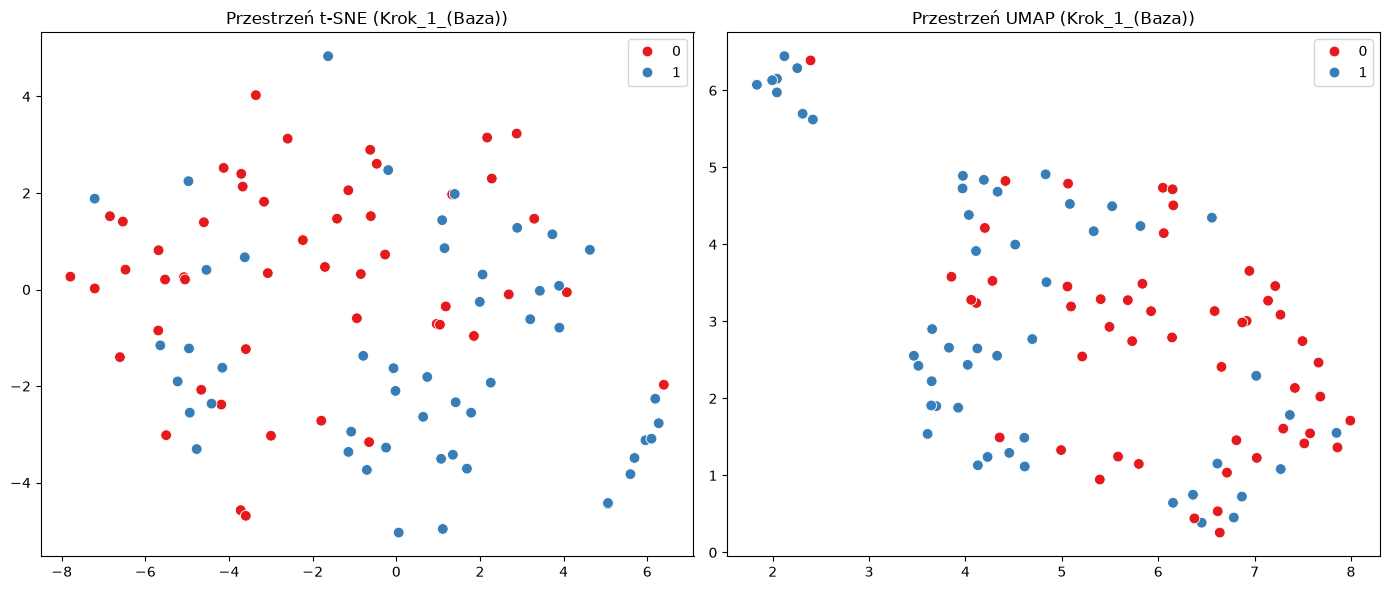

   => Zapisano wizualizację w: results_cifar_random/latent_space_Krok_1_(Baza).png

[KROK 2] Prawdopodobieństwo krawędzi i skróty Small-World
   Czas generacji: 0.7s
   => Klasyfikacja | Accuracy: 0.620 | Macro F1: 0.612 (Wymiar cech: 26)
   => Ocena zdolności rekonstrukcji (Trenowanie MLPRegressor)...
   => Rekonstrukcja | Reconstruction MSE: 0.1585
   => Generowanie wizualizacji t-SNE i UMAP...


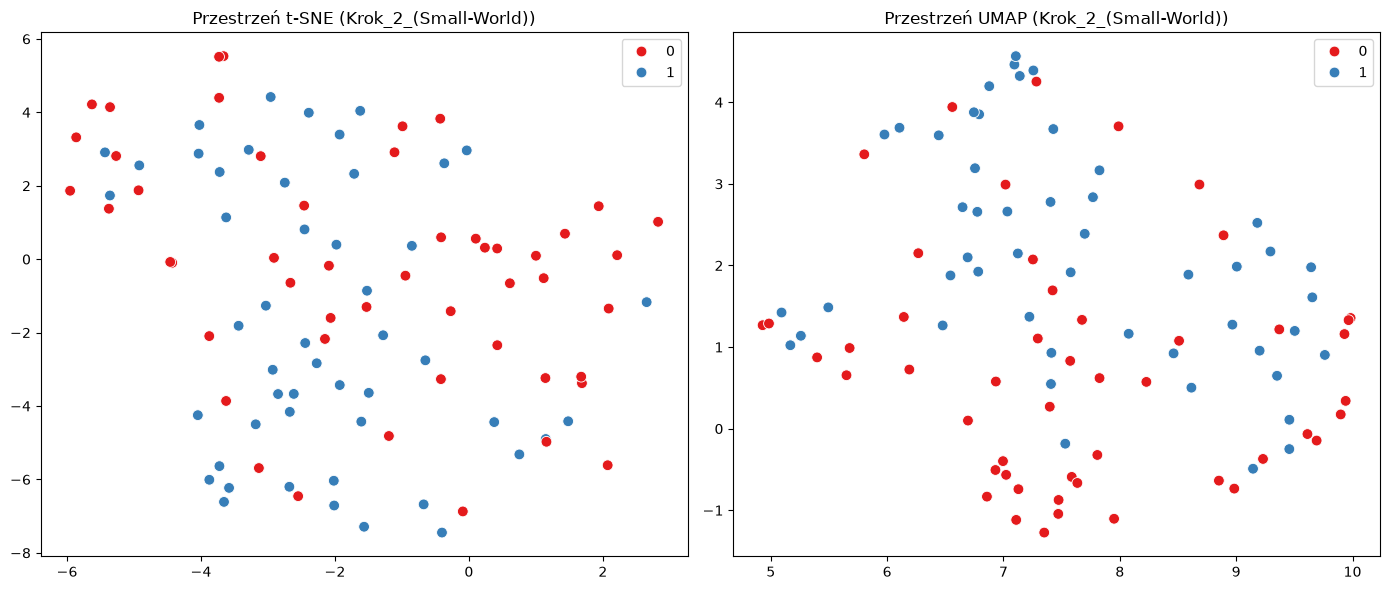

   => Zapisano wizualizację w: results_cifar_random/latent_space_Krok_2_(Small-World).png

[KROK 3] Ensembling (M=5 grafów na obraz -> Średnia + Wariancja)
   Czas generacji: 0.9s
   => Klasyfikacja | Accuracy: 0.730 | Macro F1: 0.723 (Wymiar cech: 26)
   => Ocena zdolności rekonstrukcji (Trenowanie MLPRegressor)...
   => Rekonstrukcja | Reconstruction MSE: 0.1314
   => Generowanie wizualizacji t-SNE i UMAP...


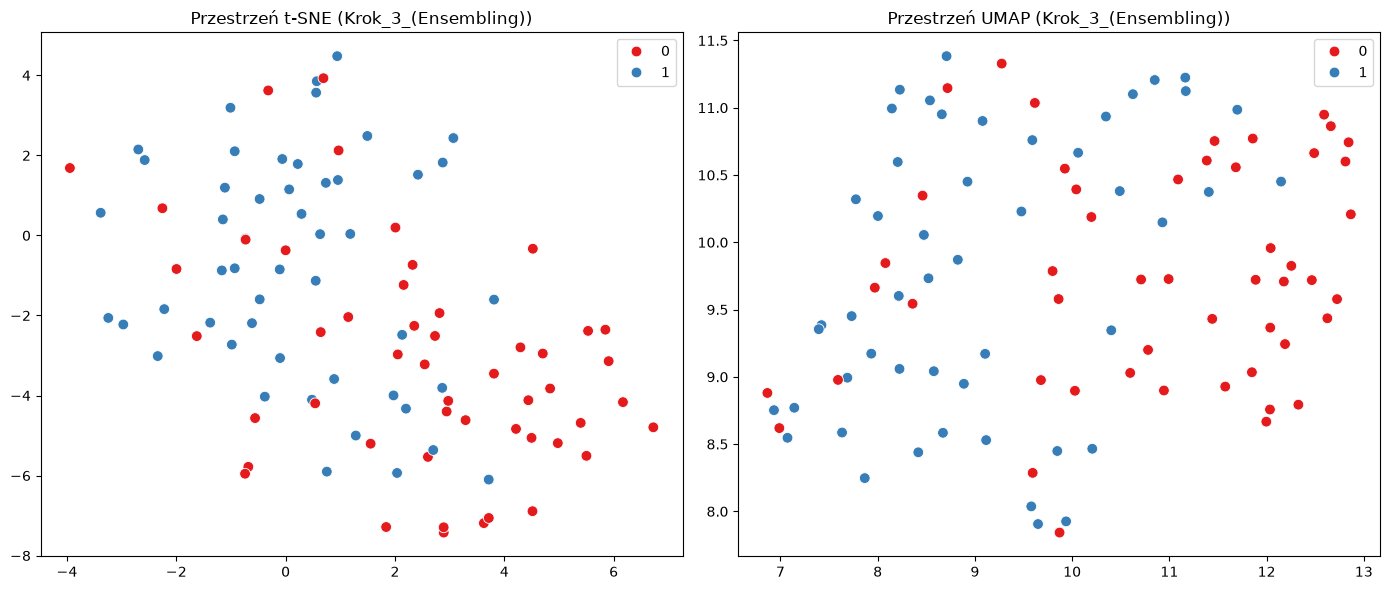

   => Zapisano wizualizację w: results_cifar_random/latent_space_Krok_3_(Ensembling).png

[KROK 4] Fuzja: Ensembling + HOG + Graf ER
   Czas generacji (doklejanie): 0.3s
   => Klasyfikacja | Accuracy: 0.810 | Macro F1: 0.805 (Wymiar cech: 327)
   => Ocena zdolności rekonstrukcji (Trenowanie MLPRegressor)...
   => Rekonstrukcja | Reconstruction MSE: 0.0807
   => Generowanie wizualizacji t-SNE i UMAP...


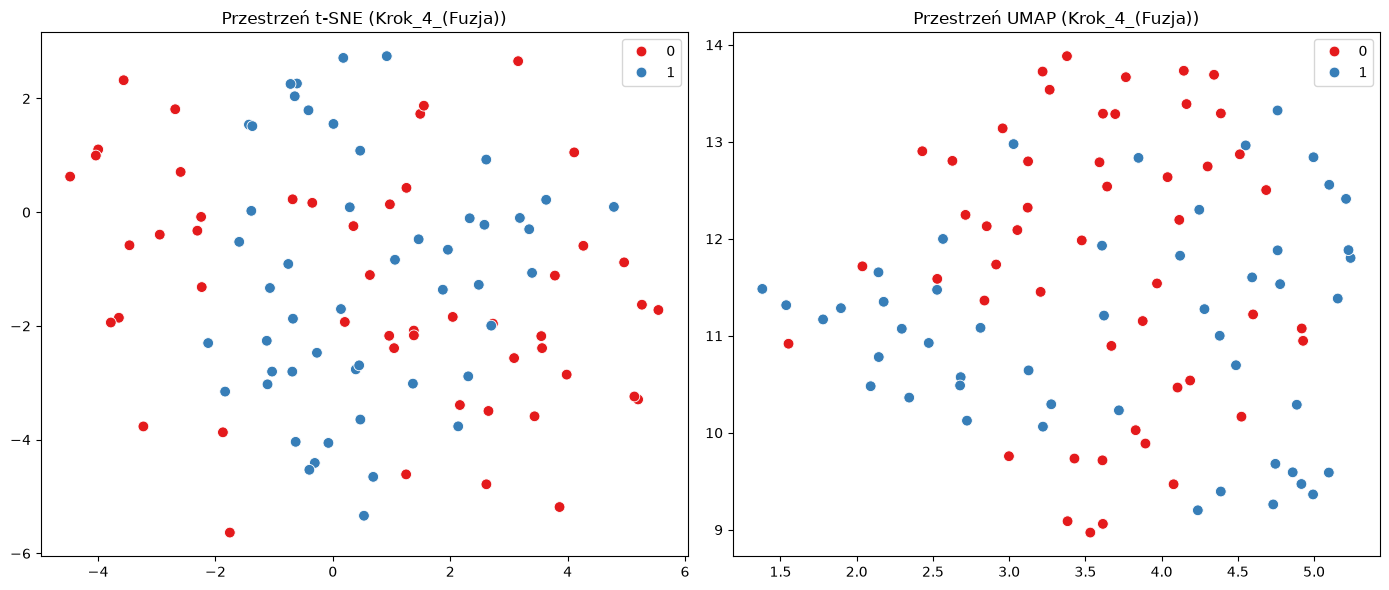

   => Zapisano wizualizację w: results_cifar_random/latent_space_Krok_4_(Fuzja).png

                ZBIORCZE PODSUMOWANIE WYNIKÓW EWALUACJI REPREZENTACJI                
Metoda                    | Accuracy     | Macro F1     | Reconstruction MSE  
------------------------------------------------------------------------------
Krok 1 (Baza)             | 0.710        | 0.704        | 0.0914              
Krok 2 (Small-World)      | 0.620        | 0.612        | 0.1585              
Krok 3 (Ensembling)       | 0.730        | 0.723        | 0.1314              
Krok 4 (Fuzja)            | 0.810        | 0.805        | 0.0807              
Wygenerowane wykresy t-SNE oraz UMAP znajdują się w folderze: results_cifar_random


In [10]:
# %% [kod] Komórka 7: Pętla Główna (Wykonanie Planu Wdrożenia z Logowaniem)
if __name__ == "__main__":
    print(f"--- Wczytywanie danych CIFAR-10 ({cfg.per_class} próbek na klasę) ---")
    images, labels = load_cifar10(cfg)
    
    # Dziennik na wyniki do zbiorczej tabeli
    results_log = []
    
    def run_step(step_name, X, y, images, cfg):
        acc, f1 = evaluate_classifiers(X, y, cfg)
        mse = evaluate_reconstruction(X, images, cfg)
        visualize_latent_space(X, y, step_name.replace(" ", "_"), cfg)
        
        results_log.append({
            "Metoda": step_name,
            "Accuracy": acc,
            "Macro F1": f1,
            "Reconstruction MSE": mse
        })
    
    # ---------------------------------------------------------------------------------
    # KROK 1: Klasyczny twardy próg (Determinizm, brak losowości)
    # ---------------------------------------------------------------------------------
    print("\n[KROK 1] Twardy Próg (Baza Deterministyczna)")
    cfg.probabilistic = False
    cfg.small_world_p = 0.0
    cfg.ensemble_m = 1
    t0 = time.time()
    X_krok1, y = build_ensemble_dataset(images, labels, cfg)
    print(f"   Czas generacji: {time.time()-t0:.1f}s")
    run_step("Krok 1 (Baza)", X_krok1, y, images, cfg)
    
    # ---------------------------------------------------------------------------------
    # KROK 2: Wstrzyknięcie Prawdopodobieństwa i Topologii Small-World (Skróty)
    # ---------------------------------------------------------------------------------
    print("\n[KROK 2] Prawdopodobieństwo krawędzi i skróty Small-World")
    cfg.probabilistic = True
    cfg.small_world_p = 0.05
    cfg.ensemble_m = 1
    t0 = time.time()
    X_krok2, y = build_ensemble_dataset(images, labels, cfg)
    print(f"   Czas generacji: {time.time()-t0:.1f}s")
    run_step("Krok 2 (Small-World)", X_krok2, y, images, cfg)
    
    # ---------------------------------------------------------------------------------
    # KROK 3: Wdrożenie Ensemblingu (Siła Tłumu)
    # ---------------------------------------------------------------------------------
    print("\n[KROK 3] Ensembling (M=5 grafów na obraz -> Średnia + Wariancja)")
    cfg.probabilistic = True
    cfg.small_world_p = 0.05
    cfg.ensemble_m = 5
    t0 = time.time()
    X_krok3, y = build_ensemble_dataset(images, labels, cfg)
    print(f"   Czas generacji: {time.time()-t0:.1f}s")
    run_step("Krok 3 (Ensembling)", X_krok3, y, images, cfg)
    
    # ---------------------------------------------------------------------------------
    # KROK 4: Fuzja "Determinizm + Losowość"
    # ---------------------------------------------------------------------------------
    print("\n[KROK 4] Fuzja: Ensembling + HOG + Graf ER")
    t0 = time.time()
    X_krok4 = build_fused_dataset(images, X_krok3, cfg)
    print(f"   Czas generacji (doklejanie): {time.time()-t0:.1f}s")
    run_step("Krok 4 (Fuzja)", X_krok4, y, images, cfg)
    
    # ---------------------------------------------------------------------------------
    # PODSUMOWANIE WYNIKÓW (Tabela)
    # ---------------------------------------------------------------------------------
    print("\n" + "="*85)
    print(f"{'ZBIORCZE PODSUMOWANIE WYNIKÓW EWALUACJI REPREZENTACJI':^85}")
    print("="*85)
    header = f"{'Metoda':<25} | {'Accuracy':<12} | {'Macro F1':<12} | {'Reconstruction MSE':<20}"
    print(header)
    print("-" * len(header))
    
    for row in results_log:
        print(f"{row['Metoda']:<25} | {row['Accuracy']:<12.3f} | {row['Macro F1']:<12.3f} | {row['Reconstruction MSE']:<20.4f}")
    print("="*85)
    print("Wygenerowane wykresy t-SNE oraz UMAP znajdują się w folderze:", cfg.out_dir)